# Leaf venation data management with phenoVein (Newsome et al. 2020)

**Paper:** Newsome, E. L., Brock, G. L., Lutz, J., & Baker, R. L. (2020).
*Variation within laminae: Semi-automated methods for quantifying leaf venation using phenoVein.*
Applications in Plant Sciences 8(5): e11346. doi:10.1002/aps3.11346

**Author code (executed verbatim):** `CompilePhenoVein.R` from
[rlbaker5/AppsInPlantSci_phenoVein](https://github.com/rlbaker5/AppsInPlantSci_phenoVein)
at commit `c753f9f17510e1dd16d20b98fb1968552d49c6ac` (R 3.6.1-era, base R only).

**Scope:** the paper's *Data management and analysis* subsection — compiling multiple
phenoVein `.csv` outputs into one rectangular data frame, using the authors' own three
sample inputs (`196.csv`, `219.csv`, `72.csv`) and self-checking against their sample
output (`compiled_phenovein_output/name_your_file.csv`).

**Execution status: Verified on a fresh Google Colab CPU runtime** (this demonstration scope only).
Not verified: the phenoVein 1.0 / MeVisLab image segmentation workflow and the paper's
statistical models (they require raw leaf images and software not provided publicly).

**Python は起動用ランチャーにすぎません**：すべての科学的処理は、著者提供の R スクリプトが
`Rscript` でそのまま実行します。Python 側はファイルのダウンロード・検証とプロセス起動のみ行います。

**日本語要約:** このノートブックは phenoVein の出力 CSV を著者の R スクリプトで
1 つの表形式データに統合する手順を再現します。著者のサンプル入力 3 ファイルを使用し、
著者のサンプル出力と一致することを確認します。実行時間は数分、ダウンロードは約 0.1 MB です。

## Runtime selection

Select **Runtime → Change runtime type → CPU** (standard, no GPU needed).
This is a small data-reshaping demonstration; GPU is neither required nor useful.

**Run all:** Runtime → Run all. Expected total time ≈ 2–5 minutes (mostly environment
checks and downloads of ~0.1 MB). No Drive mount, no credentials.

**実行環境：** CPU ランタイムを選択してください。GPU は不要です。
「ランタイム → すべてのセルを実行」で約 2〜5 分で完了します。

### Check the R runtime

The scientific step is the authors' R script, so we need `Rscript`. A standard Colab
CPU image ships R; if it is missing, we install `r-base-core` via apt.
**Python is only the launcher; the computation is R.**

**著者の R コードをそのまま実行するため `Rscript` を確認します。**
**無ければ apt で r-base-core を導入します（計算本体は R です）。**

In [ ]:
import shutil, subprocess, sys, textwrap

rscript = shutil.which("Rscript")
if rscript is None:
    print("Rscript not found; installing r-base-core via apt ...")
    subprocess.run(
        ["apt-get", "update", "-qq"],
        check=True, timeout=600,
    )
    subprocess.run(
        ["apt-get", "install", "-y", "-qq", "r-base-core"],
        check=True, timeout=1800,
    )
    rscript = shutil.which("Rscript")
assert rscript is not None, "Rscript is required but was not available"
version = subprocess.run([rscript, "--version"], capture_output=True, text=True, check=True, timeout=60)
print(version.stdout.splitlines()[0])
print("Rscript path:", rscript)

Rscript (R) version 4.6.1 (2026-06-24)
Rscript path: /usr/bin/Rscript


### Acquire the pinned inputs and the author's script

Everything is fetched from the pinned commit `c753f9f...` of the author repository via
`raw.githubusercontent.com` (public, no token). Each file is verified against its
GitHub **git blob SHA-1** (`sha1("blob <size>\0" + bytes)`) and byte size, so the bytes
are provably the pinned revision.

**コミット c753f9f からサンプル CSV・著者スクリプト・参照出力を取得し、**
**git blob SHA-1 とサイズでバイト一致性を検証します。**

In [ ]:
import hashlib, urllib.request

REPO = "rlbaker5/AppsInPlantSci_phenoVein"
COMMIT = "c753f9f17510e1dd16d20b98fb1968552d49c6ac"
RAW = f"https://raw.githubusercontent.com/{REPO}/{COMMIT}/"

# (path, expected bytes, git blob sha1) — pinned metadata from the GitHub tree API
FILES = {
    "196.csv":        (13331, "dfc301aa61745297acb1522cb3e4c56eca77281e"),
    "219.csv":        (32775, "422f25596f2a29b9c5eed71fa99aaef175d3dcc0"),
    "72.csv":         (23516, "d703b9f8e37a41ecdc823804de0b934ee69acb4d"),
    "CompilePhenoVein.R": (4937, "9d633b4eb4bde46fbd345c9f3112fbee2df57e48"),
    "compiled_phenovein_output/name_your_file.csv": (32163, "0dcafe4ae7c0b2144a418070390f31f9771b41a5"),
}

import os
os.makedirs("/content/inputs", exist_ok=True)
for rel, (size, blob_sha) in FILES.items():
    dest = os.path.join("/content/inputs", os.path.basename(rel))
    urllib.request.urlretrieve(RAW + rel, dest)
    data = open(dest, "rb").read()
    digest = hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()
    assert len(data) == size, f"{rel}: expected {size} bytes, got {len(data)}"
    assert digest == blob_sha, f"{rel}: blob sha mismatch: {digest}"
    print(f"OK  {rel:45s} {len(data):>7d} bytes  blob {digest[:12]}...")
print("All pinned inputs verified against commit", COMMIT[:12])

OK  196.csv                                         13331 bytes  blob dfc301aa6174...


OK  219.csv                                         32775 bytes  blob 422f25596f2a...


OK  72.csv                                          23516 bytes  blob d703b9f8e37a...
OK  CompilePhenoVein.R                               4937 bytes  blob 9d633b4eb4bd...


OK  compiled_phenovein_output/name_your_file.csv    32163 bytes  blob 0dcafe4ae7c0...
All pinned inputs verified against commit c753f9f17510


### Preview a phenoVein output file

phenoVein writes a semi-structured CSV: line 1 is `"Analysis name:; <id>"`, then voxel
size, observed pixels, skeleton length (mm), vein density (mm/mm²), endpoints, branch
points, areole counts, and per-areole areas (px, mm²). `CompilePhenoVein.R` parses
these by fixed row positions.

**phenoVein 出力は固定行位置の準構造 CSV です。著者スクリプトは行位置でパースします。**

In [ ]:
with open("/content/inputs/196.csv") as f:
    for i, line in enumerate(f):
        print(line.rstrip()[:120])
        if i >= 11:
            break
print("...")
print("Note: the first areole is the (removed) sum of all non-closed edge areas.")

Input file:; C:/Users/lutzjj/Desktop/Venation Project/Data 010818/196.tif
Analysis name:;196
VoxelSize_X:;0.001399;[mm];VoxelSize_Y:;0.001399;[mm]
Number of leaf pixels:;12071795
Total leaf area (from mask):;23.6269292458;[mm^2]
Total skeleton length:;121.207694247;[mm]
Average vein density:;5.1300654853;[mm mm^-2]
Number of skeleton pieces:;451
Number of skeleton end points:;140
Number of skeleton branching points:;254
Number of areoles:;65
Areole Pixels:;3796632.0;531026.0;433192.0;343617.0;287218.0;260150.0;259026.0;238866.0;237898.0;212690.0;207467.0;20091
...
Note: the first areole is the (removed) sum of all non-closed edge areas.


### Run the author's script, unmodified

The script hard-codes `setwd("~/Downloads/AppsInPlantSci_phenoVein-master")`. Instead of
editing the authors' code, we run `Rscript` with `HOME` pointed at a clean work
directory that contains that exact layout with the verified sample CSVs. The script is
the pinned `CompilePhenoVein.R` byte-for-byte.

**著者スクリプトは一切変更せず、HOME を工作ディレクトリに向けてそのまま実行します。**

In [ ]:
import pathlib, subprocess

work = pathlib.Path("/content/phenovein_work")
if work.exists():
    shutil.rmtree(work)  # keep the run deterministic
repo_dir = work / "Downloads" / "AppsInPlantSci_phenoVein-master"
repo_dir.mkdir(parents=True)
shutil.copy("/content/inputs/CompilePhenoVein.R", repo_dir / "CompilePhenoVein.R")
for name in ("196.csv", "219.csv", "72.csv"):
    shutil.copy(f"/content/inputs/{name}", repo_dir / name)

proc = subprocess.run(
    ["Rscript", "CompilePhenoVein.R"],
    cwd=repo_dir,
    env={"HOME": str(work), "PATH": os.environ["PATH"]},
    capture_output=True, text=True, timeout=600,
)
print("returncode:", proc.returncode)
if proc.stdout.strip():
    print(proc.stdout)
if proc.returncode != 0:
    print(proc.stderr)
    raise RuntimeError("CompilePhenoVein.R failed; see stderr above")
out_path = repo_dir / "compiled_phenovein_output" / "name_your_file.csv"
assert out_path.exists(), "script did not produce its output CSV"
print("Produced:", out_path)

returncode: 0
         used (Mb) gc trigger (Mb) max used (Mb)
Ncells 302258 16.2     709671   38   501045 26.8
Vcells 524084  4.0    8388608   64  1977524 15.1

Produced: /content/phenovein_work/Downloads/AppsInPlantSci_phenoVein-master/compiled_phenovein_output/name_your_file.csv


### Self-check against the authors' sample output

The authors shipped `compiled_phenovein_output/name_your_file.csv` as the expected
result. We compare it with our rerun cell-by-cell as strings (phenoVein-derived values
are kept in the script's original text form) and show summary statistics.

**著者のサンプル出力と再実行結果を文字列比較し、統計概要を表示します。**

In [ ]:
import pandas as pd

ours = pd.read_csv(out_path, dtype=str)
ref = pd.read_csv("/content/inputs/name_your_file.csv", dtype=str)

same_shape = ours.shape == ref.shape
same_content = ours.fillna("").equals(ref.fillna(""))
print("shape (rows, columns):", ours.shape, "vs reference", ref.shape)
print("column order:", list(ours.columns))
print("exact string match with authors' sample output:", same_shape and same_content)
assert same_shape, "row/column shape differs from the authors' sample output"

ours_num = ours.copy()
for col in ("vox_size", "px_obs", "skel_length_mm", "vein_density_mm2",
            "end_points", "branch_points", "areole_num"):
    ours_num[col] = pd.to_numeric(ours_num[col])
summary = (ours_num.groupby("plant")
           .agg(areoles=("areole_num", "size"),
                skeleton_mm=("skel_length_mm", "first"),
                vein_density_mm_per_mm2=("vein_density_mm2", "first"),
                endpoints=("end_points", "first"),
                branch_points=("branch_points", "first"),
                mean_areole_mm2=("areole_mmsq", lambda s: round(pd.to_numeric(s).mean(), 4)))
           .reset_index())
summary

shape (rows, columns): (350, 9) vs reference (350, 9)
column order: ['plant', 'vox_size', 'px_obs', 'skel_length_mm', 'vein_density_mm2', 'end_points', 'branch_points', 'areole_num', 'areole_mmsq']
exact string match with authors' sample output: True


,plant,areoles,skeleton_mm,vein_density_mm_per_mm2,endpoints,branch_points,mean_areole_mm2
0,196,64,121.207694,5.130065,140,254,0.2507
1,219,120,189.193112,7.923788,438,643,0.1306
2,72,166,112.271576,9.092713,145,466,0.0607


`areole_num` in the compiled frame is the count of *closed* areoles (the composite
edge area is removed, and the script subtracts 1 from the raw count), consistent with
the paper's description of the data-management step. Each plant keeps the same
`vox_size`, skeleton length and vein density across its areole rows.

**areole_num は閉じた小領域数（縁の複合領域を除去し −1 補正済み）、**
**骨格長・葉脈密度は葉ごとに一定です。**

### Distribution of areole areas (additional visualization)

A per-plant areole-area (mm²) distribution — **created for this notebook**, not a figure
from the paper.

**小領域面積の分布図（本ノートブック独自の追加可視化で、論文の図ではありません）。**

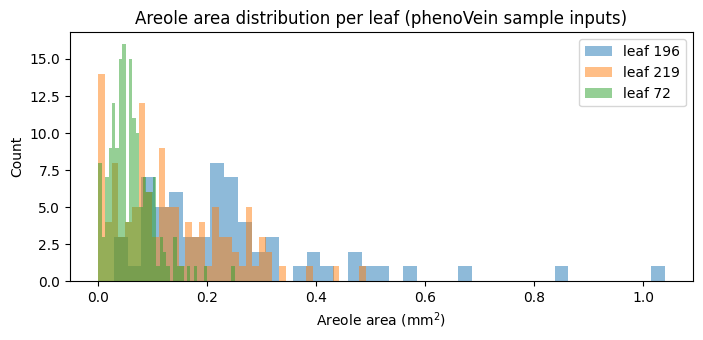

In [ ]:
import matplotlib.pyplot as plt

ours_num["areole_mm2"] = pd.to_numeric(ours["areole_mmsq"])
fig, ax = plt.subplots(figsize=(7, 3.5))
for plant, grp in ours_num.groupby("plant"):
    ax.hist(grp["areole_mm2"], bins=40, alpha=0.5, label=f"leaf {plant}")
ax.set_xlabel("Areole area (mm$^2$)")
ax.set_ylabel("Count")
ax.set_title("Areole area distribution per leaf (phenoVein sample inputs)")
ax.legend()
fig.tight_layout()
fig.savefig("/content/areole_areas.png", dpi=150)
plt.show()

## Interpretation and validation record

- **What was executed:** the authors' `CompilePhenoVein.R` (commit `c753f9f`, base R) on
  their three sample phenoVein outputs, reproducing the paper's
  *Data management and analysis* subsection ("an R script that (1) compiles data from
  multiple phenoVein .csv output files, (2) reformats the phenoVein output into a
  rectangular data frame").
- **Result:** the rerun reproduced the authors' shipped sample output exactly
  (string-identical table), giving a strong provenance check on both the script and the
  pinned inputs.
- **Not reproduced / out of scope:** phenoVein 1.0 vein segmentation (MeVisLab 2.8.2 +
  raw leaf images, not publicly provided) and the mixed-effects models of Table 2.
  Sample sizes in the paper also precluded testing crop-type effects.
- **License note:** the repository carries no license file; the notebook executes the
  authors' code in place from the pinned commit and stores nothing persistent.

**検証記録:** 著者スクリプトを pinned コミットからそのまま実行し、サンプル出力と
完全一致することを確認しました。画像解析部と統計モデルは範囲外です。

## References

1. Newsome et al. 2020, Appl. Plant Sci. 8(5):e11346, doi:10.1002/aps3.11346.
2. Bühler et al. 2015, phenoVein — A tool for leaf vein segmentation and analysis, Plant Physiology 169(4):2359–2370.
3. R Core Team (2019). R: A language and environment for statistical computing.